In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
tf.config.threading.set_intra_op_parallelism_threads(12)
tf.config.threading.set_inter_op_parallelism_threads(12)

print("Threads configured")

Threads configured


In [3]:
df = pd.read_csv('../../../datasets/diamonds.csv')

In [4]:
df.drop(columns='Unnamed: 0', inplace=True)

In [5]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [6]:
df.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(146)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 53794 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53794 non-null  float64
 1   cut      53794 non-null  str    
 2   color    53794 non-null  str    
 3   clarity  53794 non-null  str    
 4   depth    53794 non-null  float64
 5   table    53794 non-null  float64
 6   price    53794 non-null  int64  
 7   x        53794 non-null  float64
 8   y        53794 non-null  float64
 9   z        53794 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.5 MB


In [10]:
x = df.drop(columns=['price'])
y = df['price']

In [11]:
le_cut = LabelEncoder()
le_color = LabelEncoder()
le_clarity = LabelEncoder()

x['cut'] = le_cut.fit_transform(x['cut'])
x['color'] = le_color.fit_transform(x['color'])
x['clarity'] = le_clarity.fit_transform(x['clarity'])

In [12]:
x.shape

(53794, 9)

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x , y , test_size=0.2, random_state=1)

In [14]:
y_train

8578     4436
28190     666
50517    2273
16053    6412
13771    5614
         ... 
50202    2227
32600     802
5206     3780
12200    5190
33094     815
Name: price, Length: 43035, dtype: int64

In [15]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

numeric_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']
x_train_scaled[numeric_cols] = x_scaler.fit_transform(x_train_scaled[numeric_cols])
x_test_scaled[numeric_cols] = x_scaler.transform(x_test_scaled[numeric_cols])

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))

In [16]:
x_train_scaled.head()

,carat,cut,color,clarity,depth,table,x,y,z
8578,0.508292,3,1,3,-1.154155,1.141556,0.709984,0.690635,0.536439
28190,-0.839865,4,0,3,-0.105578,0.693155,-0.936610,-0.886579,-0.901553
50517,-0.207917,3,1,3,0.243947,0.693155,-0.073261,-0.093517,-0.055675
16053,1.013850,2,3,3,-0.175483,-0.203647,1.066005,1.127265,1.043966
13771,0.529356,4,4,5,1.082809,-0.652048,0.665482,0.601527,0.762007


In [26]:
model = Sequential()

model.add(Input(shape=(x_train_scaled.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))

In [27]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,705 (34.00 KB)

 Trainable params: 8,705 (34.00 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(loss='mean_squared_error', optimizer='adam')

In [29]:
history = model.fit(x_train_scaled, y_train_scaled, epochs=50, validation_split=0.2, batch_size=64)

Epoch 1/50
538/538 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1002 - val_loss: 0.0788
Epoch 2/50
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0626 - val_loss: 0.0667
Epoch 3/50
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0525 - val_loss: 0.0584
Epoch 4/50
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0448 - val_loss: 0.0477
Epoch 5/50
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0400 - val_loss: 0.0441
Epoch 6/50
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0367 - val_loss: 0.0400
Epoch 7/50
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0330 - val_loss: 0.0348
Epoch 8/50
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0307 - val_loss: 0.0382
Epoch 9/50
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0296 - val_loss: 0.0368
Epoch 10/50
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0275 - val_loss: 0.0367
Epoch 11/50
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0259 - val_loss: 0.0306
Epoch 12/50
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

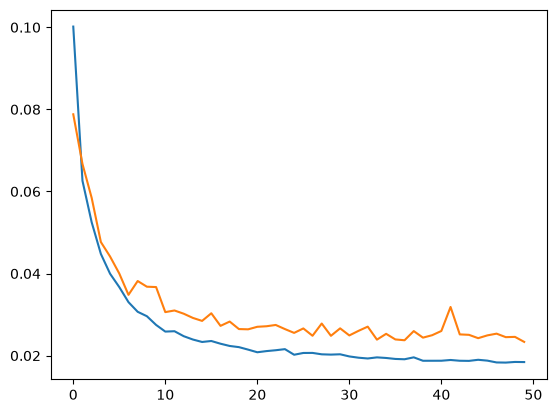

In [30]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

In [31]:
y_pred_scaled = model.predict(x_test_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

337/337 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [32]:
r2_score(y_test, y_pred)

0.980884313583374